In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
new_base_dir = '/content/drive/My Drive/intel dataset'

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

inputs = keras.Input(shape=(150, 150, 3))
x = layers.Rescaling(1./255)(inputs)
x = layers.Conv2D(filters=32, kernel_size=3, activation="relu", padding="same")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu", padding="same")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu", padding="same")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu", padding="same")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=512, kernel_size=3, activation="relu", padding="same")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=1024, kernel_size=3, activation="relu", padding="same")(x)
x = layers.Flatten()(x)
outputs = layers.Dense(6, activation="softmax")(x)
model = keras.Model(inputs=inputs, outputs=outputs)
model.summary()

model.compile(loss="categorical_crossentropy",
              optimizer="rmsprop",
              metrics=["accuracy"])

Model: "functional_52"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_28 (InputLayer)     │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_21 (Rescaling)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_126 (Conv2D)             │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_105               │ (None, 75, 75, 32)     │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_127 (Conv2D)             │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_106               │ (None, 37, 37, 64)     │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_128 (Conv2D)             │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_107               │ (None, 18, 18, 128)    │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_129 (Conv2D)             │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_108               │ (None, 9, 9, 256)      │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_130 (Conv2D)             │ (None, 9, 9, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_109               │ (None, 4, 4, 512)      │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_131 (Conv2D)             │ (None, 4, 4, 1024)     │     4,719,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_21 (Flatten)            │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 6)              │        98,310 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,386,502 (24.36 MB)

 Trainable params: 6,386,502 (24.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(loss="categorical_crossentropy",
              optimizer="rmsprop",
              metrics=["accuracy"])

In [ ]:
from tensorflow.keras.utils import image_dataset_from_directory

train_dataset = image_dataset_from_directory(
    new_base_dir + "/train",
    label_mode='categorical',
    image_size=(150, 150),
    batch_size=16,
    validation_split=0.3,
    subset="training",
    seed=123)

validation_dataset = image_dataset_from_directory(
    new_base_dir + "/train",
    label_mode='categorical',
    image_size=(150, 150),
    batch_size=16,
    validation_split=0.3,
    subset="validation",
    seed=123)

test_dataset = image_dataset_from_directory(
    new_base_dir + "/test",
    label_mode='categorical',
    image_size=(150, 150),
    batch_size=16)

Found 864 files belonging to 6 classes.
Using 605 files for training.
Found 864 files belonging to 6 classes.
Using 259 files for validation.
Found 600 files belonging to 6 classes.


In [ ]:
class_names = train_dataset.class_names
print(class_names)

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [ ]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="scene_convnet.keras",
        save_best_only=True,
        monitor="val_loss")
]
history = model.fit(
    train_dataset,
    epochs=20,
    validation_data=validation_dataset,
    callbacks=callbacks)

Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 124ms/step - accuracy: 0.1868 - loss: 1.8124 - val_accuracy: 0.1313 - val_loss: 1.7953
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.2860 - loss: 1.9465 - val_accuracy: 0.4595 - val_loss: 1.3714
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.3835 - loss: 1.5072 - val_accuracy: 0.4981 - val_loss: 1.2055
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.4364 - loss: 1.3993 - val_accuracy: 0.4749 - val_loss: 1.2283
Epoch 5/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.4975 - loss: 1.2627 - val_accuracy: 0.3359 - val_loss: 1.8040
Epoch 6/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.5455 - loss: 1.1813 - val_accuracy: 0.4942 - val_loss: 1.1763
Epoch 7/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.5868 - loss: 1.0893 - val_accuracy: 0.4672 - val_loss: 1.3503
Epoch 8/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.5851 - loss: 1.0283 - val_accuracy: 0.5946 - 

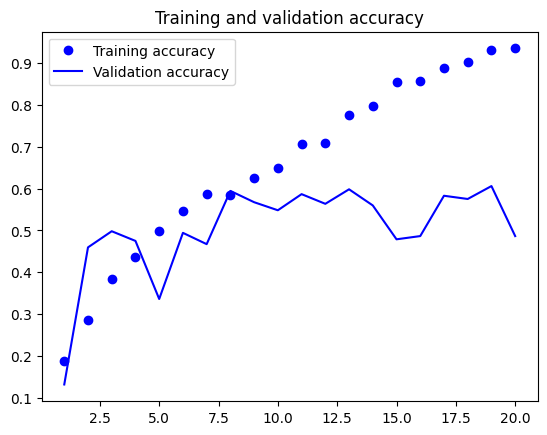

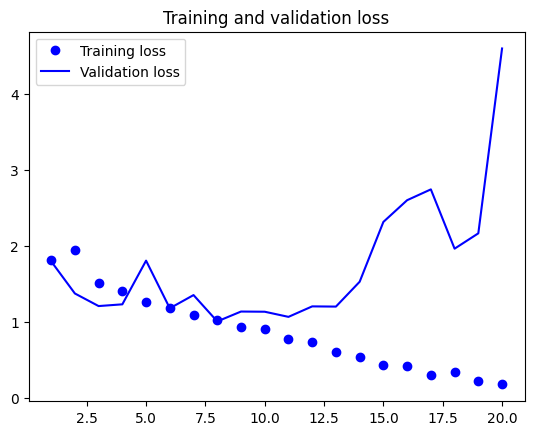

In [ ]:
import matplotlib.pyplot as plt
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy) + 1)
plt.plot(epochs, accuracy, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [ ]:
EPOCHS_ELBOW = 8

inputs = keras.Input(shape=(150, 150, 3))
x = layers.Rescaling(1./255)(inputs)
x = layers.Conv2D(filters=32, kernel_size=3, activation="relu", padding="same")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu", padding="same")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu", padding="same")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu", padding="same")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=512, kernel_size=3, activation="relu", padding="same")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=1024, kernel_size=3, activation="relu", padding="same")(x)
x = layers.Flatten()(x)
outputs = layers.Dense(6, activation="softmax")(x)
model = keras.Model(inputs=inputs, outputs=outputs)

model.compile(loss="categorical_crossentropy", optimizer="rmsprop", metrics=["accuracy"])

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="scene_convnet_retrained.keras",
        save_best_only=True,
        monitor="val_loss")
]
history = model.fit(
    train_dataset,
    epochs=EPOCHS_ELBOW,
    validation_data=validation_dataset,
    callbacks=callbacks)

Epoch 1/8
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 124ms/step - accuracy: 0.2017 - loss: 1.9663 - val_accuracy: 0.1274 - val_loss: 1.8327
Epoch 2/8
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.2545 - loss: 1.8378 - val_accuracy: 0.3745 - val_loss: 1.5509
Epoch 3/8
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.3719 - loss: 1.5034 - val_accuracy: 0.4440 - val_loss: 1.3712
Epoch 4/8
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.4347 - loss: 1.3654 - val_accuracy: 0.4633 - val_loss: 1.3651
Epoch 5/8
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.4876 - loss: 1.2930 - val_accuracy: 0.5521 - val_loss: 1.1239
Epoch 6/8
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.5488 - loss: 1.1628 - val_accuracy: 0.5174 - val_loss: 1.2774
Epoch 7/8
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.5967 - loss: 1.0902 - val_accuracy: 0.6062 - val_loss: 1.0128
Epoch 8/8
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.6182 - loss: 0.9956 - val_accuracy: 0.5019 - val_loss

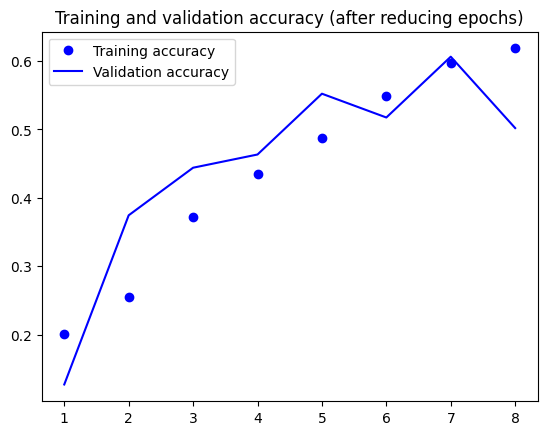

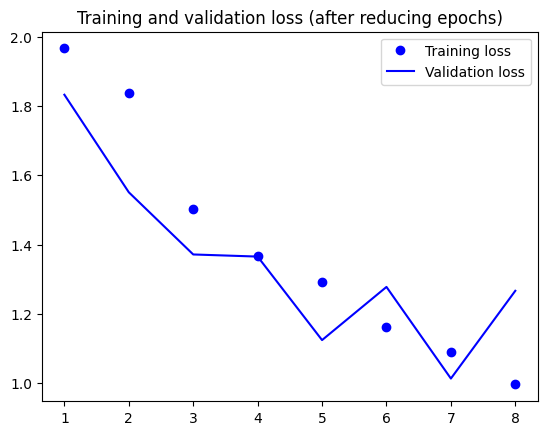

In [ ]:
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy) + 1)
plt.plot(epochs, accuracy, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy (after reducing epochs)")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss (after reducing epochs)")
plt.legend()
plt.show()

In [ ]:
test_model = keras.models.load_model("scene_convnet_retrained.keras")
test_loss, test_acc = test_model.evaluate(test_dataset)
print(f"Test accuracy (without augmentation, retrained): {test_acc:.3f}")

38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.5750 - loss: 1.0766
Test accuracy (without augmentation, retrained): 0.575


In [ ]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("vertical"),
        layers.RandomRotation(0.3),
        layers.RandomZoom(0.3),
    ]
)

In [ ]:
inputs = keras.Input(shape=(150, 150, 3))
x = data_augmentation(inputs)
x = layers.Rescaling(1./255)(x)
x = layers.Conv2D(filters=32, kernel_size=3, activation="relu", padding="same")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu", padding="same")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu", padding="same")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu", padding="same")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=512, kernel_size=3, activation="relu", padding="same")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=1024, kernel_size=3, activation="relu", padding="same")(x)
x = layers.Flatten()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(6, activation="softmax")(x)
model = keras.Model(inputs=inputs, outputs=outputs)

model.compile(loss="categorical_crossentropy",
              optimizer="rmsprop",
              metrics=["accuracy"])

In [ ]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="scene_convnet_with_augmentation.keras",
        save_best_only=True,
        monitor="val_loss")
]
history = model.fit(
    train_dataset,
    epochs=20,
    validation_data=validation_dataset,
    callbacks=callbacks)

Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.2231 - loss: 1.8397 - val_accuracy: 0.3591 - val_loss: 1.6851
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.3256 - loss: 1.8165 - val_accuracy: 0.3127 - val_loss: 1.5688
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.3223 - loss: 1.6121 - val_accuracy: 0.1351 - val_loss: 2.1465
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.3405 - loss: 1.6206 - val_accuracy: 0.3938 - val_loss: 1.4246
Epoch 5/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.2959 - loss: 1.5903 - val_accuracy: 0.4093 - val_loss: 1.5011
Epoch 6/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.3752 - loss: 1.4607 - val_accuracy: 0.3977 - val_loss: 1.3264
Epoch 7/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.3934 - loss: 1.4634 - val_accuracy: 0.2510 - val_loss: 1.9901
Epoch 8/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.3851 - loss: 1.4578 - val_accuracy: 0.3127 - v

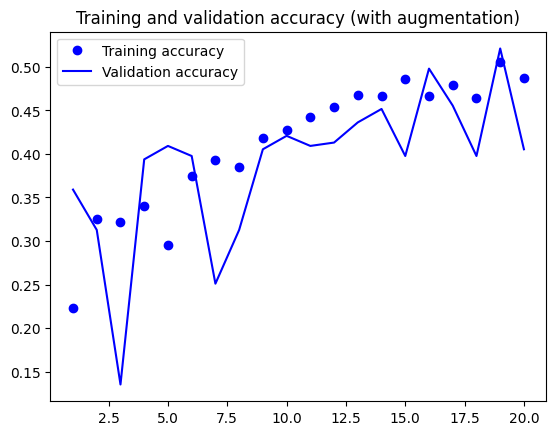

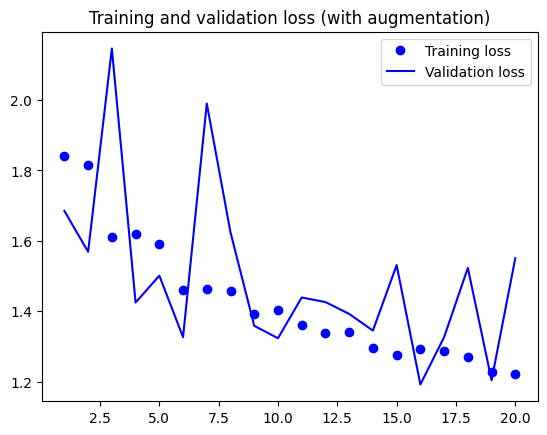

In [ ]:
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy) + 1)
plt.plot(epochs, accuracy, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy (with augmentation)")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss (with augmentation)")
plt.legend()
plt.show()

In [ ]:
test_model = keras.models.load_model("scene_convnet_with_augmentation.keras")
test_loss, test_acc = test_model.evaluate(test_dataset)
print(f"Test accuracy (with augmentation): {test_acc:.3f}")

38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.4733 - loss: 1.2777
Test accuracy (with augmentation): 0.473


## Comparison: Without Augmentation vs With Augmentation

Test accuracy without augmentation: 57.5%
Test accuracy with augmentation: 47.3%

The model without augmentation performed better (57.5% vs 47.3%). This is
because the dataset is very small (only 100 images across 6 classes), and
the augmentation used here (RandomRotation 0.3 and RandomZoom 0.3) was
fairly aggressive. On such a small dataset, this much rotation and zoom
distorts the images enough that the model struggles to recognize the
original features (like the straight lines of buildings, or the horizon
in sea/glacier images). Normally, augmentation helps reduce overfitting
and improves generalization, but here the dataset was already too small
for the model to learn from, so the augmentation added extra noise instead
of helping. This is reflected in the lower training and validation accuracy
of the augmented model, and ultimately its lower test accuracy as well.

In [ ]:
import os
print(os.listdir(new_base_dir + "/test/forest"))

['21001.jpg', '20996.jpg', '20929.jpg', '21020.jpg', '20930.jpg', '20782.jpg', '20927.jpg', '20947.jpg', '20938.jpg', '20958.jpg', '20833.jpg', '20900.jpg', '20916.jpg', '20756.jpg', '20794.jpg', '20785.jpg', '20779.jpg', '20774.jpg', '20761.jpg', '20596.jpg', '20686.jpg', '20831.jpg', '20717.jpg', '20894.jpg', '20714.jpg', '20660.jpg', '20740.jpg', '20638.jpg', '20685.jpg', '20754.jpg', '20533.jpg', '20650.jpg', '20674.jpg', '20400.jpg', '20447.jpg', '20544.jpg', '20416.jpg', '20885.jpg', '21016.jpg', '20384.jpg', '21018.jpg', '20556.jpg', '20328.jpg', '20978.jpg', '20582.jpg', '20984.jpg', '20411.jpg', '20619.jpg', '20800.jpg', '20134.jpg', '20288.jpg', '20108.jpg', '20728.jpg', '20816.jpg', '20605.jpg', '20117.jpg', '20147.jpg', '20510.jpg', '20242.jpg', '20925.jpg', '20173.jpg', '20225.jpg', '20175.jpg', '20315.jpg', '20502.jpg', '20260.jpg', '20159.jpg', '20620.jpg', '20150.jpg', '20825.jpg', '20485.jpg', '20439.jpg', '20718.jpg', '20731.jpg', '20801.jpg', '20330.jpg', '20166.jpg'

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

def predict_image_class(img_path, model, class_names):
    img = image.load_img(img_path, target_size=(150, 150))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    predictions = model.predict(img_array)
    predicted_index = np.argmax(predictions[0])
    predicted_class = class_names[predicted_index]
    print(f"Predicted class: {predicted_class}")
    return predicted_class

# Example use:
predict_image_class(new_base_dir + "/test/forest/20095.jpg", test_model, class_names)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step
Predicted class: forest


'forest'